In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

### Chargement du dataset normalisé

In [3]:
df = pd.read_csv('../tracks_dataset_normalized.csv')
print(f"📊 Dataset normalisé chargé : {df.shape[0]} lignes × {df.shape[1]} colonnes")

📊 Dataset normalisé chargé : 887 lignes × 19 colonnes


### CORRÉLATIONS ENTRE CONTEXTES ET CARACTÉRISTIQUES MUSICALES


📊 1. ANALYSE DES CORRÉLATIONS
----------------------------------------
🎵 Caractéristiques audio analysées : 8
🌍 Contextes analysés : 6

🔗 CORRÉLATIONS CONTEXTE ↔ CARACTÉRISTIQUES AUDIO :
-------------------------------------------------------

📋 TEMPOREL :
   • energie         : r =  0.244 ***
   • valence         : r =  0.372 ***
   • danceability    : r =  0.335 ***
   • acousticness    : r = -0.134 ***

📋 METEO :
   • energie         : r = -0.245 ***
   • valence         : r = -0.756 ***
   • danceability    : r = -0.447 ***
   • bpm_estime      : r = -0.214 ***

📋 ACTIVITE :
   • energie         : r =  0.446 ***
   • valence         : r = -0.171 ***
   • danceability    : r =  0.310 ***
   • acousticness    : r = -0.222 ***
   • speechiness     : r = -0.113 ***
   • bpm_estime      : r =  0.461 ***

📋 EMOTIONNEL :
   • energie         : r = -0.417 ***
   • valence         : r = -0.150 ***
   • danceability    : r = -0.365 ***
   • acousticness    : r =  0.284 ***
   • bpm_estime  

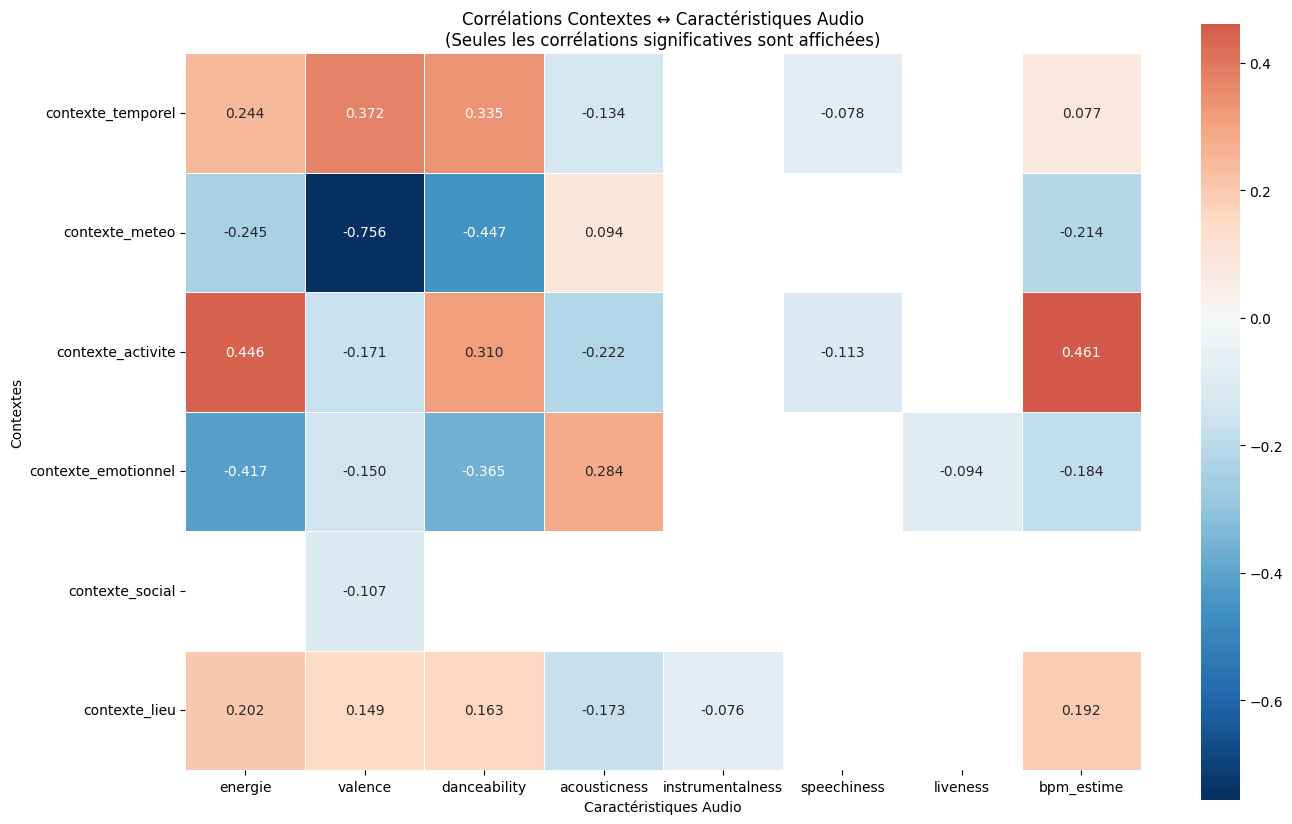

In [8]:
print("\n📊 1. ANALYSE DES CORRÉLATIONS")
print("-" * 40)

# Identification des colonnes
context_columns = [col for col in df.columns if 'contexte_' in col]
audio_features = ['energie', 'valence', 'danceability', 'acousticness', 
                 'instrumentalness', 'speechiness', 'liveness', 'bpm_estime']

# Filtrer les caractéristiques audio présentes dans le dataset
available_audio_features = [f for f in audio_features if f in df.columns]

print(f"🎵 Caractéristiques audio analysées : {len(available_audio_features)}")
print(f"🌍 Contextes analysés : {len(context_columns)}")

# Fonction pour calculer les corrélations entre contextes catégoriels et variables numériques
def calculate_context_correlations(df, context_col, audio_features):
    """Calcule les corrélations entre un contexte et les caractéristiques audio"""
    correlations = {}
    
    # Encoder le contexte catégoriel
    le = LabelEncoder()
    context_encoded = le.fit_transform(df[context_col].fillna('unknown'))
    
    for feature in audio_features:
        if feature in df.columns:
            # Calculer la corrélation de Pearson
            corr, p_value = pearsonr(context_encoded, df[feature])
            correlations[feature] = {
                'correlation': corr,
                'p_value': p_value,
                'significant': p_value < 0.05
            }
    
    return correlations, le.classes_

print("\n🔗 CORRÉLATIONS CONTEXTE ↔ CARACTÉRISTIQUES AUDIO :")
print("-" * 55)

# Matrice de corrélations pour visualisation
correlation_matrix = pd.DataFrame()
significance_matrix = pd.DataFrame()

all_correlations = {}

for context_col in context_columns:
    print(f"\n📋 {context_col.upper().replace('CONTEXTE_', '')} :")
    
    correlations, classes = calculate_context_correlations(df, context_col, available_audio_features)
    all_correlations[context_col] = correlations
    
    # Stocker pour la matrice
    corr_values = []
    sig_values = []
    
    for feature in available_audio_features:
        if feature in correlations:
            corr = correlations[feature]['correlation']
            sig = correlations[feature]['significant']
            corr_values.append(corr)
            sig_values.append(sig)
            
            # Affichage des corrélations significatives
            if abs(corr) > 0.1 and sig:  # Seuil de 0.1 et significatif
                significance = "***" if correlations[feature]['p_value'] < 0.001 else "**" if correlations[feature]['p_value'] < 0.01 else "*"
                print(f"   • {feature:15} : r = {corr:6.3f} {significance}")
    
    correlation_matrix[context_col] = corr_values
    significance_matrix[context_col] = sig_values

# Configuration de l'index pour la matrice
correlation_matrix.index = available_audio_features
significance_matrix.index = available_audio_features

# Visualisation de la matrice de corrélations
print(f"\n📈 MATRICE DE CORRÉLATIONS GLOBALE :")
print("-" * 35)

plt.figure(figsize=(14, 10))
mask = ~significance_matrix.astype(bool)  # Masquer les corrélations non significatives

sns.heatmap(correlation_matrix.T, 
           annot=True, 
           cmap='RdBu_r', 
           center=0,
           mask=mask.T,
           square=True,
           linewidths=0.5,
           fmt='.3f',
           cbar_kws={"shrink": .8})

plt.title('Corrélations Contextes ↔ Caractéristiques Audio\n(Seules les corrélations significatives sont affichées)')
plt.xlabel('Caractéristiques Audio')
plt.ylabel('Contextes')
plt.tight_layout()
plt.show()

### PATTERNS : QUELS GENRES POUR QUELS CONTEXTES ?


🎼 2. ANALYSE DES PATTERNS GENRE ↔ CONTEXTE
---------------------------------------------
🔍 DISTRIBUTION DES GENRES PAR CONTEXTE :
----------------------------------------

📊 TEMPOREL :
   🎯 Associations fortes (>20%) :
      • weekend → pop : 94.6%
      • apres_midi → pop : 63.9%
      • journee → pop : 57.7%
      • nuit → folk : 42.9%
      • matin → jazz : 35.3%

📊 METEO :
   🎯 Associations fortes (>20%) :
      • chaud → pop : 90.8%
      • ensoleille → pop : 87.8%
      • nuageux → blues : 58.8%
      • neutre → pop : 43.5%
      • froid → classical : 40.0%

📊 ACTIVITE :
   🎯 Associations fortes (>20%) :
      • fete → pop : 91.2%
      • cuisine → pop : 79.8%
      • conduite → pop : 79.8%
      • sport → pop : 71.7%
      • detente → pop : 67.2%

📊 EMOTIONNEL :
   🎯 Associations fortes (>20%) :
      • joyeux → pop : 94.9%
      • energique → pop : 82.2%
      • romantique → pop : 67.2%
      • motive → pop : 62.9%
      • calme → folk : 54.2%

📊 SOCIAL :
   🎯 Associations for

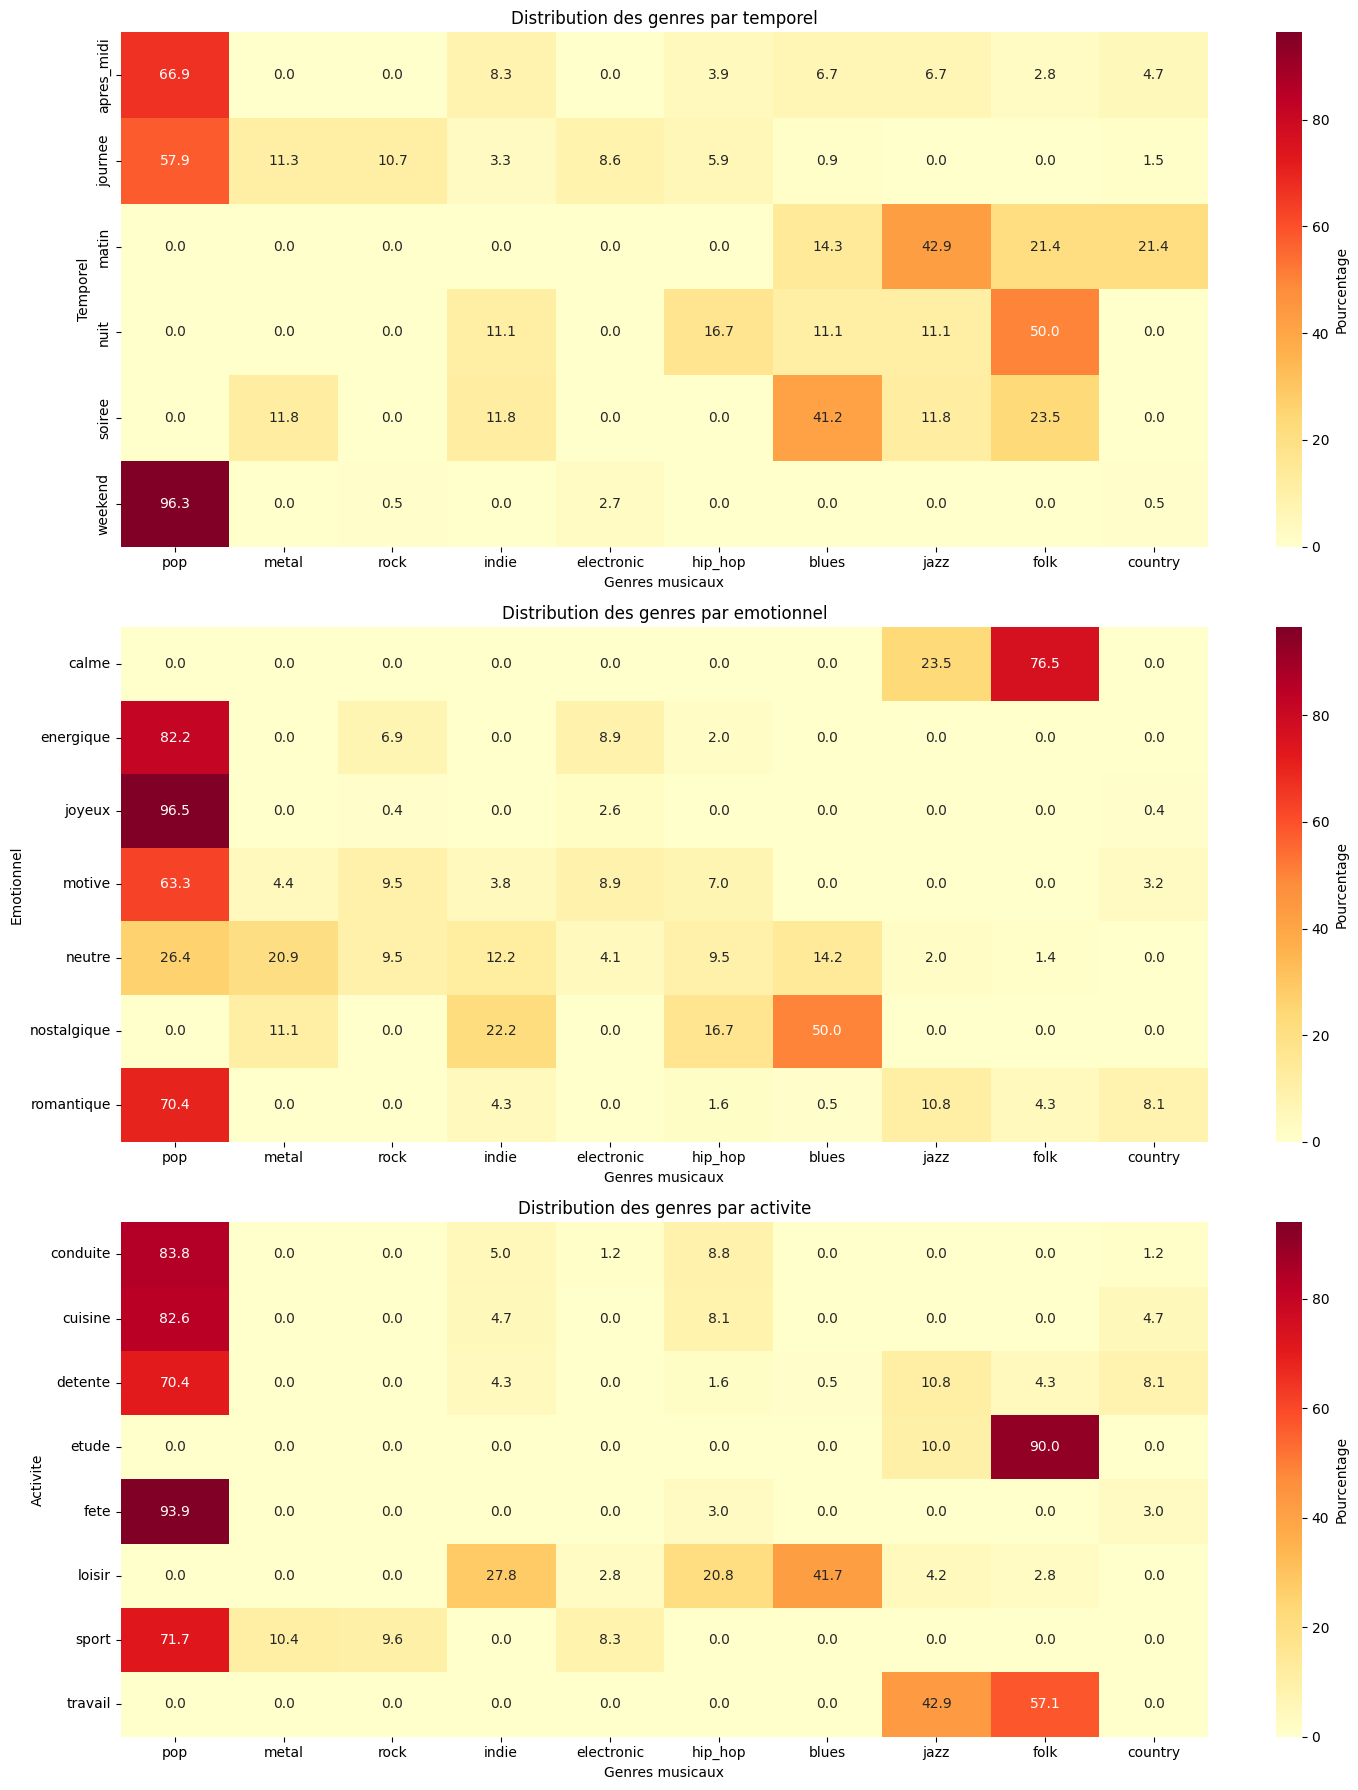

In [10]:
print("\n🎼 2. ANALYSE DES PATTERNS GENRE ↔ CONTEXTE")
print("-" * 45)

if 'genre' in df.columns:
    print("🔍 DISTRIBUTION DES GENRES PAR CONTEXTE :")
    print("-" * 40)
    
    # Analyse pour chaque contexte
    genre_context_analysis = {}
    
    for context_col in context_columns:
        print(f"\n📊 {context_col.upper().replace('CONTEXTE_', '')} :")
        
        # Tableau croisé dynamique
        crosstab = pd.crosstab(df[context_col], df['genre'], normalize='index') * 100
        
        # Trouver les associations les plus fortes (> 20% dans un contexte)
        strong_associations = []
        for context_value in crosstab.index:
            for genre in crosstab.columns:
                percentage = crosstab.loc[context_value, genre]
                if percentage > 20:  # Seuil de 20%
                    strong_associations.append((context_value, genre, percentage))
        
        # Trier par pourcentage décroissant
        strong_associations.sort(key=lambda x: x[2], reverse=True)
        
        # Afficher les top associations
        genre_context_analysis[context_col] = strong_associations
        
        if strong_associations:
            print("   🎯 Associations fortes (>20%) :")
            for context_val, genre, pct in strong_associations[:5]:
                print(f"      • {context_val} → {genre} : {pct:.1f}%")
        else:
            print("   ℹ️  Aucune association forte détectée")
    
    # Visualisation des patterns les plus significatifs
    print(f"\n📊 VISUALISATION DES PATTERNS PRINCIPAUX :")
    print("-" * 40)
    
    # Sélectionner les contextes les plus intéressants pour la visualisation
    interesting_contexts = ['contexte_temporel', 'contexte_emotionnel', 'contexte_activite']
    available_interesting = [ctx for ctx in interesting_contexts if ctx in context_columns]
    
    if len(available_interesting) > 0:
        fig, axes = plt.subplots(len(available_interesting), 1, figsize=(15, 6*len(available_interesting)))
        if len(available_interesting) == 1:
            axes = [axes]
        
        for i, context_col in enumerate(available_interesting):
            # Calculer le tableau croisé
            crosstab = pd.crosstab(df[context_col], df['genre'])
            
            # Prendre les top 10 genres les plus fréquents
            top_genres = df['genre'].value_counts().head(10).index
            crosstab_filtered = crosstab[top_genres]
            
            # Normaliser par ligne (pourcentage par contexte)
            crosstab_pct = crosstab_filtered.div(crosstab_filtered.sum(axis=1), axis=0) * 100
            
            # Créer la heatmap
            sns.heatmap(crosstab_pct, 
                       annot=True, 
                       fmt='.1f',
                       cmap='YlOrRd',
                       ax=axes[i],
                       cbar_kws={'label': 'Pourcentage'})
            
            axes[i].set_title(f'Distribution des genres par {context_col.replace("contexte_", "")}')
            axes[i].set_ylabel(context_col.replace("contexte_", "").title())
            axes[i].set_xlabel('Genres musicaux')
        
        plt.tight_layout()
        plt.show()


### PRÉFÉRENCES PAR MOMENT DE LA JOURNÉE


🕐 3. ANALYSE DES PRÉFÉRENCES PAR MOMENT
------------------------------------------
📊 CARACTÉRISTIQUES AUDIO MOYENNES PAR MOMENT :
--------------------------------------------------
                   energie  valence  danceability  acousticness  \
contexte_temporel                                                 
apres_midi           0.628    0.757         0.662         0.620   
journee              0.829    0.684         0.771         0.515   
matin                0.464    0.642         0.501         0.714   
nuit                 0.438    0.606         0.484         0.760   
soiree               0.493    0.506         0.498         0.750   
weekend              0.810    0.879         0.825         0.517   

                   instrumentalness  speechiness  liveness  bpm_estime  
contexte_temporel                                                       
apres_midi                    0.217        0.077     0.189     120.586  
journee                       0.227        0.083     0.205    

<Figure size 1500x1000 with 0 Axes>

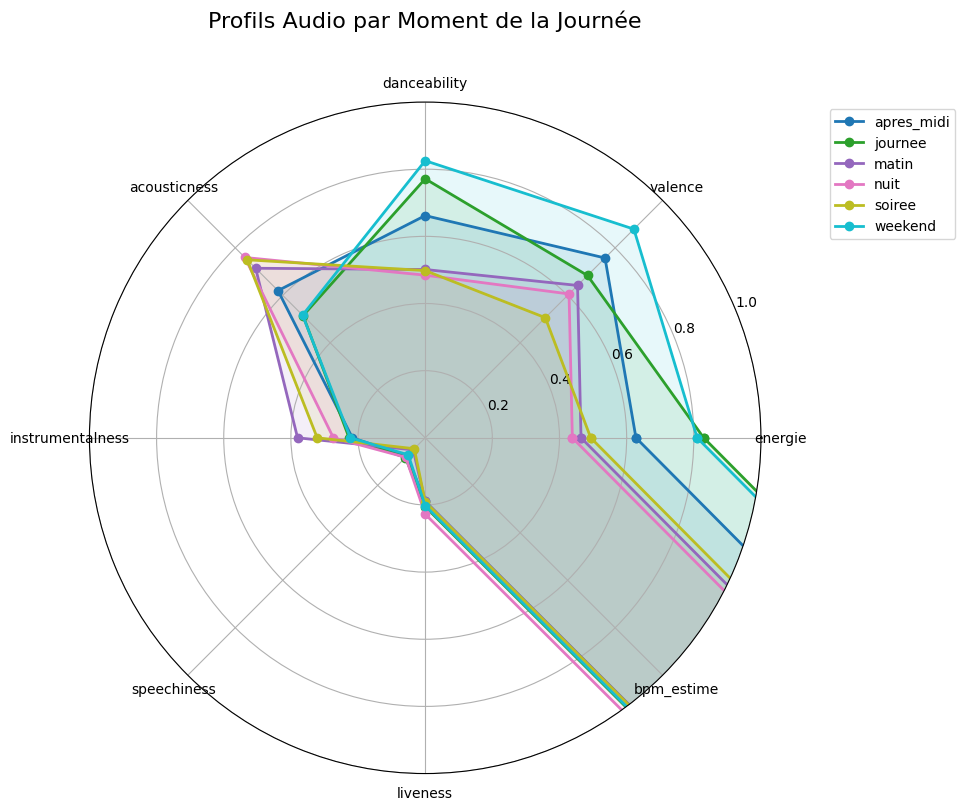

In [13]:
print("\n🕐 3. ANALYSE DES PRÉFÉRENCES PAR MOMENT")
print("-" * 42)

if 'contexte_temporel' in df.columns:
    temporal_analysis = df.groupby('contexte_temporel')[available_audio_features].mean()
    
    print("📊 CARACTÉRISTIQUES AUDIO MOYENNES PAR MOMENT :")
    print("-" * 50)
    print(temporal_analysis.round(3))
    
    # Identifier les patterns temporels les plus marqués
    print(f"\n🎯 PATTERNS TEMPORELS SIGNIFICATIFS :")
    print("-" * 35)
    
    for feature in available_audio_features:
        feature_by_time = temporal_analysis[feature]
        max_time = feature_by_time.idxmax()
        min_time = feature_by_time.idxmin()
        difference = feature_by_time.max() - feature_by_time.min()
        
        if difference > 0.1:  # Différence significative
            print(f"   🎵 {feature:15} : MAX à {max_time} ({feature_by_time.max():.3f})")
            print(f"      {'':15}   MIN à {min_time} ({feature_by_time.min():.3f})")
    
    # Visualisation des préférences temporelles
    plt.figure(figsize=(15, 10))
    
    # Graphique radar pour montrer les profils temporels
    moments = temporal_analysis.index
    n_moments = len(moments)
    
    if n_moments > 1:
        angles = np.linspace(0, 2*np.pi, len(available_audio_features), endpoint=False).tolist()
        angles += angles[:1]  # Compléter le cercle
        
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
        
        colors = plt.cm.tab10(np.linspace(0, 1, n_moments))
        
        for i, moment in enumerate(moments):
            values = temporal_analysis.loc[moment, available_audio_features].tolist()
            values += values[:1]  # Compléter le cercle
            
            ax.plot(angles, values, 'o-', linewidth=2, label=moment, color=colors[i])
            ax.fill(angles, values, alpha=0.1, color=colors[i])
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(available_audio_features)
        ax.set_ylim(0, 1)
        ax.set_title('Profils Audio par Moment de la Journée', size=16, y=1.1)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
        ax.grid(True)
        
        plt.tight_layout()
        plt.show()

### IMPACT DE LA MÉTÉO SUR LES CHOIX MUSICAUX


🌤️ 4. IMPACT DE LA MÉTÉO
-------------------------
📊 CARACTÉRISTIQUES MOYENNES PAR MÉTÉO :
----------------------------------------
                energie  valence  danceability  acousticness  \
contexte_meteo                                                 
chaud             0.776    0.847         0.792         0.550   
ensoleille        0.775    0.849         0.782         0.549   
froid             0.336    0.561         0.371         0.751   
neutre            0.708    0.664         0.687         0.569   
nuageux           0.700    0.397         0.625         0.614   
pluvieux          0.680    0.417         0.591         0.639   

                instrumentalness  speechiness  liveness  bpm_estime  
contexte_meteo                                                       
chaud                      0.223        0.076     0.204     134.236  
ensoleille                 0.215        0.072     0.196     132.719  
froid                      0.438        0.058     0.213      84.000  
neut

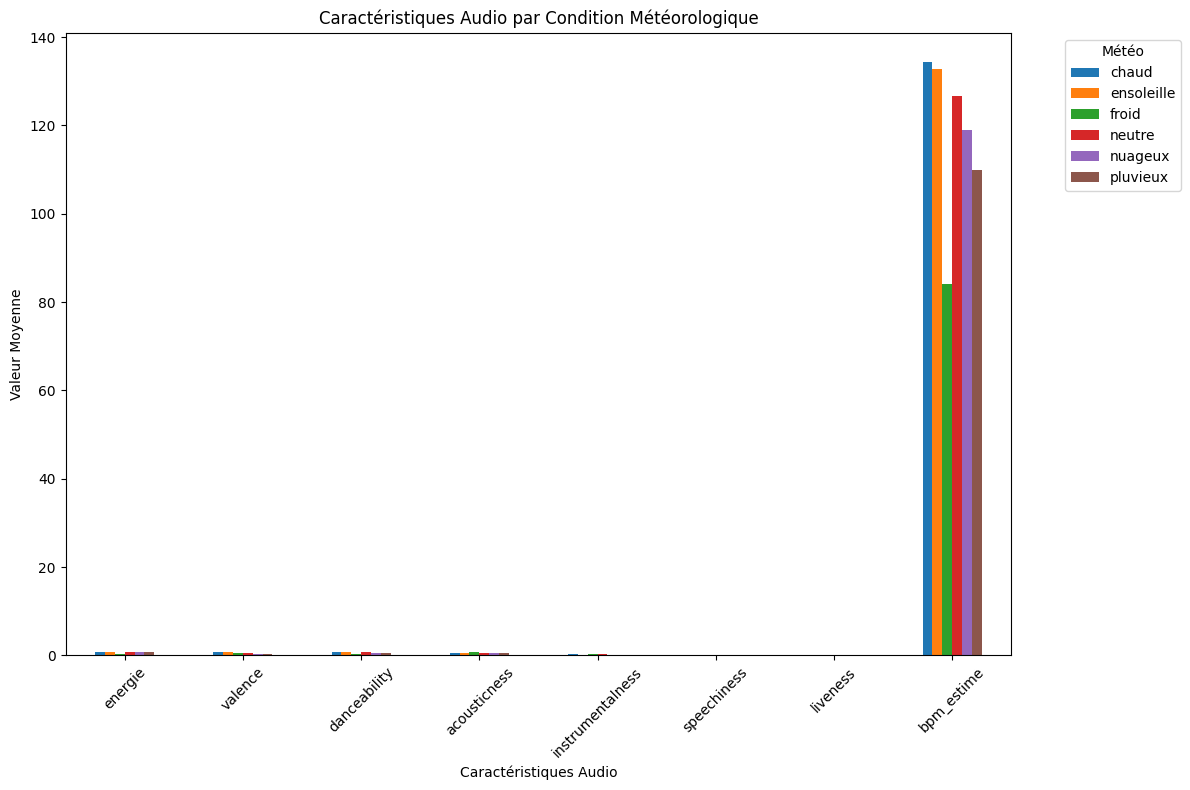

In [16]:
print("\n🌤️ 4. IMPACT DE LA MÉTÉO")
print("-" * 25)

if 'contexte_meteo' in df.columns:
    weather_analysis = df.groupby('contexte_meteo')[available_audio_features].mean()
    
    print("📊 CARACTÉRISTIQUES MOYENNES PAR MÉTÉO :")
    print("-" * 40)
    print(weather_analysis.round(3))
    
    # Analyse des effets météorologiques
    print(f"\n🌈 EFFETS MÉTÉOROLOGIQUES NOTABLES :")
    print("-" * 35)
    
    for feature in available_audio_features:
        weather_feature = weather_analysis[feature]
        if len(weather_feature) > 1:
            max_weather = weather_feature.idxmax()
            min_weather = weather_feature.idxmin()
            difference = weather_feature.max() - weather_feature.min()
            
            if difference > 0.05:  # Seuil plus bas pour la météo
                print(f"   🎵 {feature:15} : {max_weather} > {min_weather}")
                print(f"      {'':15}   Δ = {difference:.3f}")
    
    # Tests statistiques pour la météo
    print(f"\n📈 TESTS DE SIGNIFICATIVITÉ :")
    print("-" * 30)
    
    weather_values = df['contexte_meteo'].unique()
    if len(weather_values) > 2:
        from scipy.stats import f_oneway
        
        for feature in available_audio_features[:4]:  # Limiter aux 4 principales
            groups = [df[df['contexte_meteo'] == weather][feature].dropna() 
                     for weather in weather_values]
            
            # ANOVA pour tester les différences entre groupes météo
            if all(len(group) > 1 for group in groups):
                f_stat, p_value = f_oneway(*groups)
                significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
                print(f"   {feature:15} : F = {f_stat:6.3f}, p = {p_value:.4f} {significance}")
    
    # Visualisation météo
    if len(weather_analysis) > 1:
        plt.figure(figsize=(12, 8))
        weather_analysis.T.plot(kind='bar', ax=plt.gca())
        plt.title('Caractéristiques Audio par Condition Météorologique')
        plt.xlabel('Caractéristiques Audio')
        plt.ylabel('Valeur Moyenne')
        plt.legend(title='Météo', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

### DISTRIBUTION DES ÉMOTIONS DANS LE DATASET


😊 5. ANALYSE DES ÉMOTIONS
------------------------------
📊 DISTRIBUTION DES ÉMOTIONS :
------------------------------
   😊 joyeux          :  235 ( 26.5%)
   😊 romantique      :  195 ( 22.0%)
   😊 motive          :  159 ( 17.9%)
   😊 neutre          :  154 ( 17.4%)
   😊 energique       :  101 ( 11.4%)
   😊 calme           :   24 (  2.7%)
   😊 nostalgique     :   19 (  2.1%)

🎭 PROFILS AUDIO PAR ÉMOTION :
------------------------------
                     energie  valence  danceability  acousticness  \
contexte_emotionnel                                                 
calme                  0.336    0.646         0.427         0.777   
energique              0.867    0.748         0.818         0.518   
joyeux                 0.806    0.879         0.818         0.519   
motive                 0.792    0.699         0.754         0.535   
neutre                 0.731    0.595         0.680         0.496   
nostalgique            0.631    0.439         0.573         0.727   
romantiq

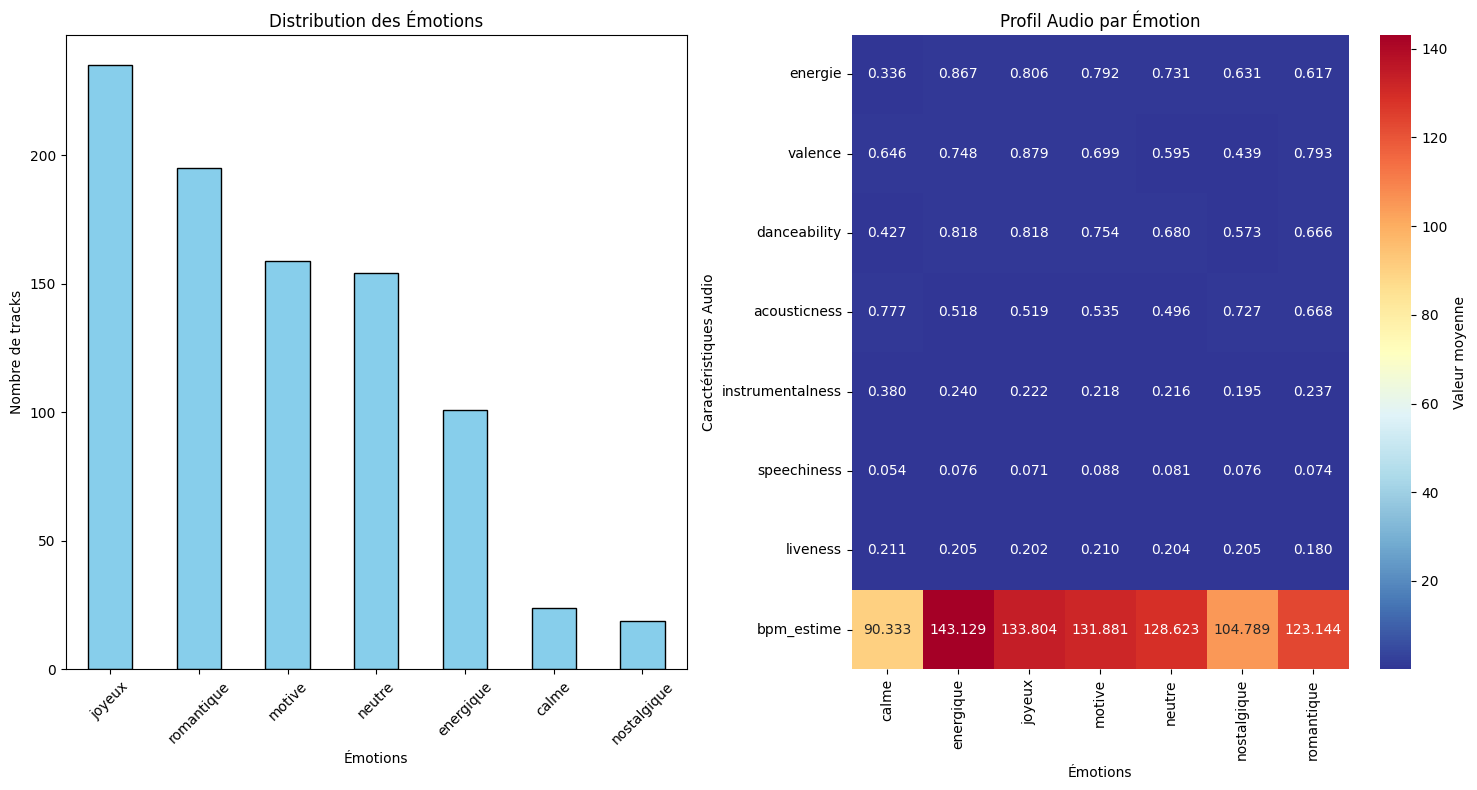

In [19]:
print("\n😊 5. ANALYSE DES ÉMOTIONS")
print("-" * 30)

if 'contexte_emotionnel' in df.columns:
    emotion_counts = df['contexte_emotionnel'].value_counts()
    
    print("📊 DISTRIBUTION DES ÉMOTIONS :")
    print("-" * 30)
    for emotion, count in emotion_counts.items():
        percentage = (count / len(df)) * 100
        print(f"   😊 {emotion:15} : {count:4d} ({percentage:5.1f}%)")
    
    # Analyse des caractéristiques par émotion
    emotion_analysis = df.groupby('contexte_emotionnel')[available_audio_features].mean()
    
    print(f"\n🎭 PROFILS AUDIO PAR ÉMOTION :")
    print("-" * 30)
    print(emotion_analysis.round(3))
    
    # Identification des émotions extrêmes
    print(f"\n🎯 CARACTÉRISTIQUES ÉMOTIONNELLES MARQUÉES :")
    print("-" * 45)
    
    for feature in available_audio_features:
        emotion_feature = emotion_analysis[feature]
        max_emotion = emotion_feature.idxmax()
        min_emotion = emotion_feature.idxmin()
        
        print(f"   🎵 {feature:15} : {max_emotion} ({emotion_feature.max():.3f}) → {min_emotion} ({emotion_feature.min():.3f})")
    
    # Visualisation des émotions
    plt.figure(figsize=(15, 8))
    
    # Graphique en barres pour la distribution
    plt.subplot(1, 2, 1)
    emotion_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Distribution des Émotions')
    plt.xlabel('Émotions')
    plt.ylabel('Nombre de tracks')
    plt.xticks(rotation=45)
    
    # Heatmap des caractéristiques par émotion
    plt.subplot(1, 2, 2)
    sns.heatmap(emotion_analysis.T, 
               annot=True, 
               fmt='.3f',
               cmap='RdYlBu_r',
               cbar_kws={'label': 'Valeur moyenne'})
    plt.title('Profil Audio par Émotion')
    plt.xlabel('Émotions')
    plt.ylabel('Caractéristiques Audio')
    
    plt.tight_layout()
    plt.show()

### SYNTHÈSE DES INSIGHTS DÉCOUVERTS

In [22]:
print("\n🎯 SYNTHÈSE DES INSIGHTS")
print("=" * 50)

print("📊 CORRÉLATIONS PRINCIPALES DÉCOUVERTES :")
print("-" * 40)

# Synthèse des corrélations les plus fortes
strong_correlations = []
for context, correlations in all_correlations.items():
    for feature, stats in correlations.items():
        if abs(stats['correlation']) > 0.15 and stats['significant']:
            strong_correlations.append({
                'context': context.replace('contexte_', ''),
                'feature': feature,
                'correlation': stats['correlation'],
                'strength': 'forte' if abs(stats['correlation']) > 0.3 else 'modérée'
            })

# Trier par force de corrélation
strong_correlations.sort(key=lambda x: abs(x['correlation']), reverse=True)

for i, corr in enumerate(strong_correlations[:10]):  # Top 10
    print(f"   {i+1:2d}. {corr['context']:12} ↔ {corr['feature']:15} : r = {corr['correlation']:6.3f} ({corr['strength']})")

print(f"\n🎼 PATTERNS GENRE-CONTEXTE IDENTIFIÉS :")
print("-" * 35)

# Synthèse des patterns genre-contexte
pattern_count = 0
for context, associations in genre_context_analysis.items():
    if associations:
        print(f"   📋 {context.replace('contexte_', '').title()} :")
        for context_val, genre, pct in associations[:3]:  # Top 3 par contexte
            print(f"      • {context_val} → {genre} ({pct:.1f}%)")
        pattern_count += len(associations)

print(f"\n📈 STATISTIQUES FINALES :")
print("-" * 25)
print(f"   🔗 Corrélations significatives trouvées : {len(strong_correlations)}")
print(f"   🎯 Patterns genre-contexte identifiés : {pattern_count}")
print(f"   🎵 Caractéristiques audio analysées : {len(available_audio_features)}")
print(f"   🌍 Contextes analysés : {len(context_columns)}")

if 'genre' in df.columns:
    print(f"   🎼 Genres musicaux dans l'analyse : {df['genre'].nunique()}")

print(f"\n🎉 ANALYSE EXPLORATOIRE TERMINÉE !")
print("   📋 Insights collectés pour la phase Machine Learning")
print("   🎯 Patterns identifiés pour les recommandations contextuelles")

# Sauvegarde des insights pour usage futur
insights_summary = {
    'strong_correlations': strong_correlations,
    'genre_patterns': genre_context_analysis,
    'audio_features_analyzed': available_audio_features,
    'contexts_analyzed': context_columns
}

# On peut sauvegarder ces insights dans un fichier JSON si nécessaire
import json
with open('../analysis_insights.json', 'w', encoding='utf-8') as f:
    json.dump(insights_summary, f, indent=2, ensure_ascii=False)

print(f"   💾 Insights sauvegardés dans 'analysis_insights.json'")


🎯 SYNTHÈSE DES INSIGHTS
📊 CORRÉLATIONS PRINCIPALES DÉCOUVERTES :
----------------------------------------
    1. meteo        ↔ valence         : r = -0.756 (forte)
    2. activite     ↔ bpm_estime      : r =  0.461 (forte)
    3. meteo        ↔ danceability    : r = -0.447 (forte)
    4. activite     ↔ energie         : r =  0.446 (forte)
    5. emotionnel   ↔ energie         : r = -0.417 (forte)
    6. temporel     ↔ valence         : r =  0.372 (forte)
    7. emotionnel   ↔ danceability    : r = -0.365 (forte)
    8. temporel     ↔ danceability    : r =  0.335 (forte)
    9. activite     ↔ danceability    : r =  0.310 (forte)
   10. emotionnel   ↔ acousticness    : r =  0.284 (modérée)

🎼 PATTERNS GENRE-CONTEXTE IDENTIFIÉS :
-----------------------------------
   📋 Temporel :
      • weekend → pop (94.6%)
      • apres_midi → pop (63.9%)
      • journee → pop (57.7%)
   📋 Meteo :
      • chaud → pop (90.8%)
      • ensoleille → pop (87.8%)
      • nuageux → blues (58.8%)
   📋 Activ